In [1]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd

# Plotting options, change to your liking
sc.set_figure_params(figsize=(3, 3), frameon=False)

In [2]:
###Load Data
adata = sc.read_h5ad('/weka/labs/kzhang/kzhang-lab-scratch/blake/HKAv2/HKAv2_pvFIB_Subset_12172025.h5ad')
adata

AnnData object with n_obs × n_vars = 3679 × 36588
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'source', 'assay', 'experiment', 'patient', 'specimen', 'condition_level3', 'condition_level2', 'condition_level1', 'condition', 'percent_cortex', 'percent_medulla', 'region_level3', 'region_level2', 'region_level1', 'age_binned', 'sex', 'race', 'KDIGO_stage', 'baseline_eGFR_binned', 'proteinuria_binned', 'A1c_binned', 'albuminuria_binned', 'diabetes_history', 'diabetes_duration', 'hypertension_history', 'hypertension_duration', 'on_RAAS_blockade', 'ckd_stageC', 'location', 'laterality', 'protocol', 'tissue_type_full', 'tissue_type', 'v2.clusters', 'v2.subclass.full', 'v2.subclass.l3', 'v2.subclass.l2', 'v2.subclass.l1', 'v2.state.l2', 'v2.state.l1', 'v2.class', 'v2.structure'
    var: 'var.features', 'var.features.rank'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'data'

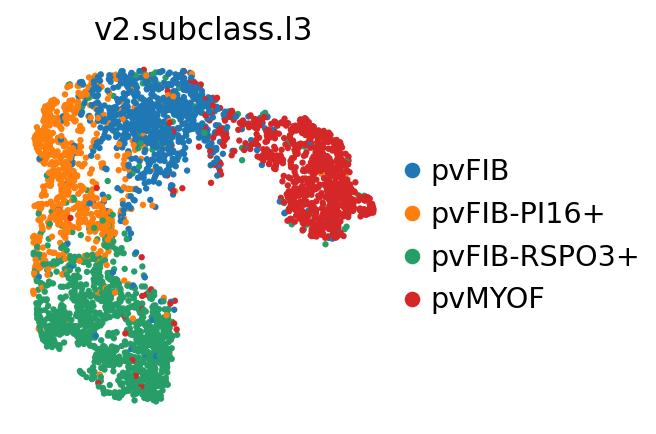

In [4]:
sc.pl.umap(adata, color=["v2.subclass.l3"], ncols=1)

In [5]:
root_celltype = "pvFIB-PI16+"

sc.pp.neighbors(adata, use_rep="X_pca", n_pcs=20)
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, use_rep="X_diffmap")
sc.tl.paga(adata, groups="v2.subclass.l3")
iroot = np.flatnonzero(adata.obs["v2.subclass.l3"] == root_celltype)[0]
adata.uns["iroot"] = iroot
sc.tl.dpt(adata)

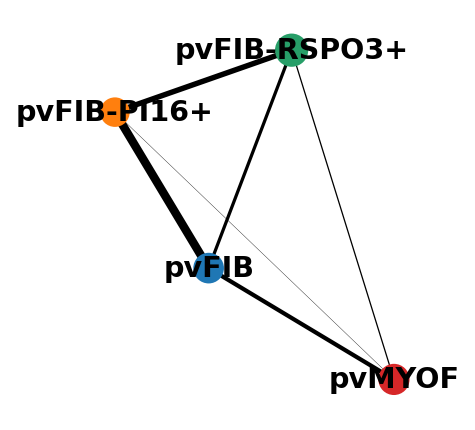

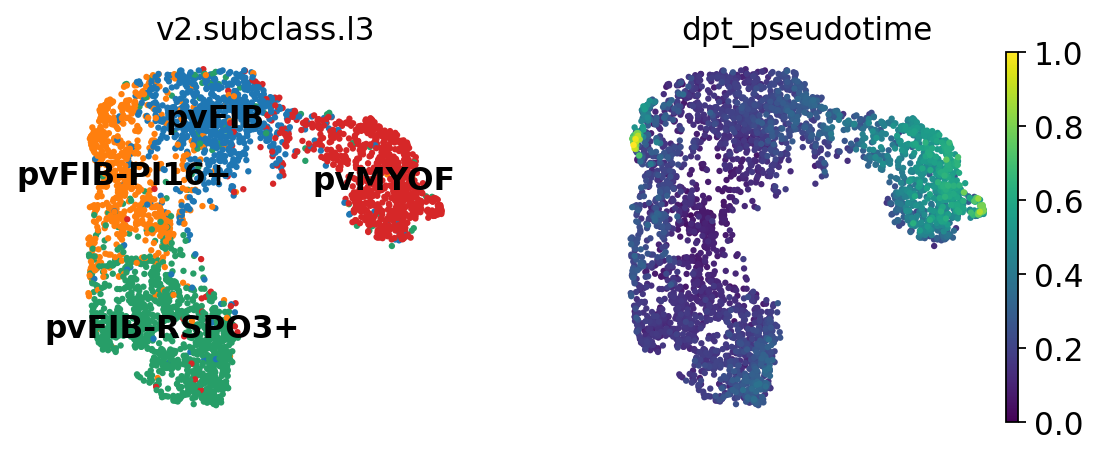

In [6]:
sc.pl.paga(adata, color=["v2.subclass.l3"],
save='PAGA_pvFIB_dpt_paga.png')
sc.pl.umap(adata, color=["v2.subclass.l3", "dpt_pseudotime"], legend_loc="on data",
save='PAGA_pvFIB_dpt_umap.png')

In [7]:
# read in trajectory (Perivascular_FIB) TF-Gene interactions from scMEGA
tf_gene = pd.read_csv('/weka/blake/Projects/Human_Kidney/Atlas_V2/trajectories/Perivascular_FIB_TF-Gene_Weight_Table.txt', sep='\t')
tf_gene

,source,target,weight
0,CEBPB,SORBS1,-0.975070
1,CEBPB,TNS1,-0.972729
2,CEBPB,RBPMS,-0.971751
3,CEBPB,TBC1D1,-0.971365
4,CEBPB,OAF,0.970579
...,...,...,...
15995,ZBTB7C,MAP3K20-AS1,-0.659713
15996,ZBTB7C,LAMA3,-0.659266
15997,ZBTB7C,PTH2R,0.658845
15998,ZBTB7C,SERPING1,0.657400


In [8]:
dc.mt.ulm(data=adata, net=tf_gene)

In [9]:
score = dc.pp.get_obsm(adata=adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 3679 × 32
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'source', 'assay', 'experiment', 'patient', 'specimen', 'condition_level3', 'condition_level2', 'condition_level1', 'condition', 'percent_cortex', 'percent_medulla', 'region_level3', 'region_level2', 'region_level1', 'age_binned', 'sex', 'race', 'KDIGO_stage', 'baseline_eGFR_binned', 'proteinuria_binned', 'A1c_binned', 'albuminuria_binned', 'diabetes_history', 'diabetes_duration', 'hypertension_history', 'hypertension_duration', 'on_RAAS_blockade', 'ckd_stageC', 'location', 'laterality', 'protocol', 'tissue_type_full', 'tissue_type', 'v2.clusters', 'v2.subclass.full', 'v2.subclass.l3', 'v2.subclass.l2', 'v2.subclass.l1', 'v2.state.l2', 'v2.state.l1', 'v2.class', 'v2.structure', 'dpt_pseudotime'
    uns: 'v2.subclass.l3_colors', 'neighbors', 'diffmap_evals', 'paga', 'v2.subclass.l3_sizes', 'iroot'
    obsm: 'X_pca', 'X_umap', 'X_diffmap', 'score_ulm', 'padj_ulm'

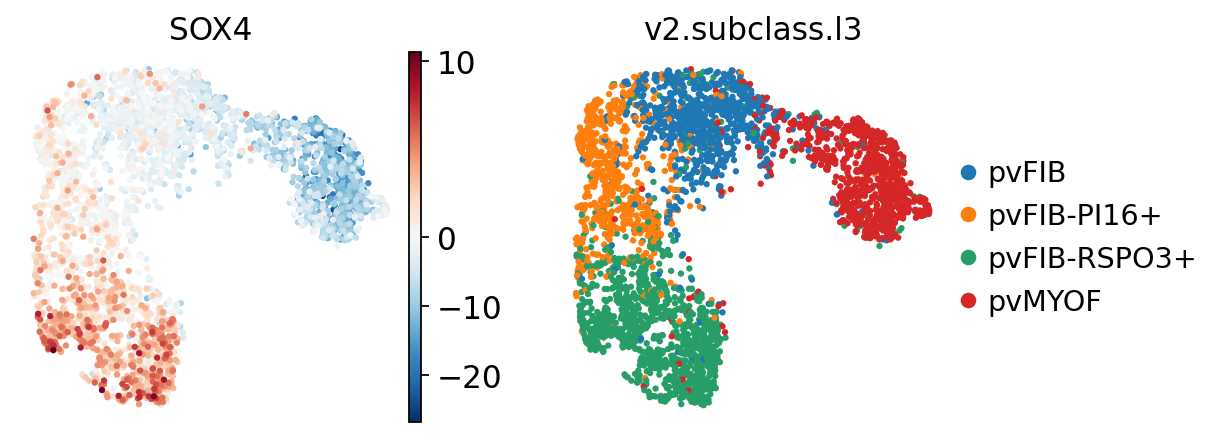

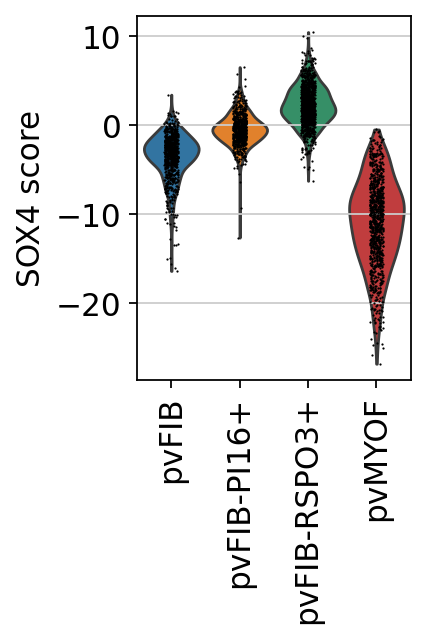

In [11]:
tf = "SOX4"
sc.pl.umap(score, color=[tf, "v2.subclass.l3"], cmap="RdBu_r", vcenter=0,
save='PAGA_pvFIB_dpt_umap_SOX4.png')
sc.pl.violin(score, keys=[tf], groupby="v2.subclass.l3", rotation=90, ylabel=f"{tf} score",
save='PAGA_pvFIB_dpt_umap_SOX4_violin.png')

In [12]:
tfs = dc.tl.rankby_order(
    adata=score,
    order="dpt_pseudotime",
    stat="dcor",
)
tfs

,name,stat,pval,padj
0,RUNX1,1743.679775,0.0,0.0
1,RUNX2,1743.131851,0.0,0.0
2,STAT3,1674.172613,0.0,0.0
3,MEF2A,1586.848354,0.0,0.0
4,GLI2,1584.941448,0.0,0.0
5,NR2F1,1584.225453,0.0,0.0
6,MEF2C,1558.151125,0.0,0.0
7,NR4A2,1507.216371,0.0,0.0
8,NFIL3,1504.970851,0.0,0.0
9,SOX4,1374.468985,0.0,0.0


In [13]:
top_tfs = tfs.head(5)["name"].to_list()
top_tfs

['RUNX1', 'RUNX2', 'STAT3', 'MEF2A', 'GLI2']

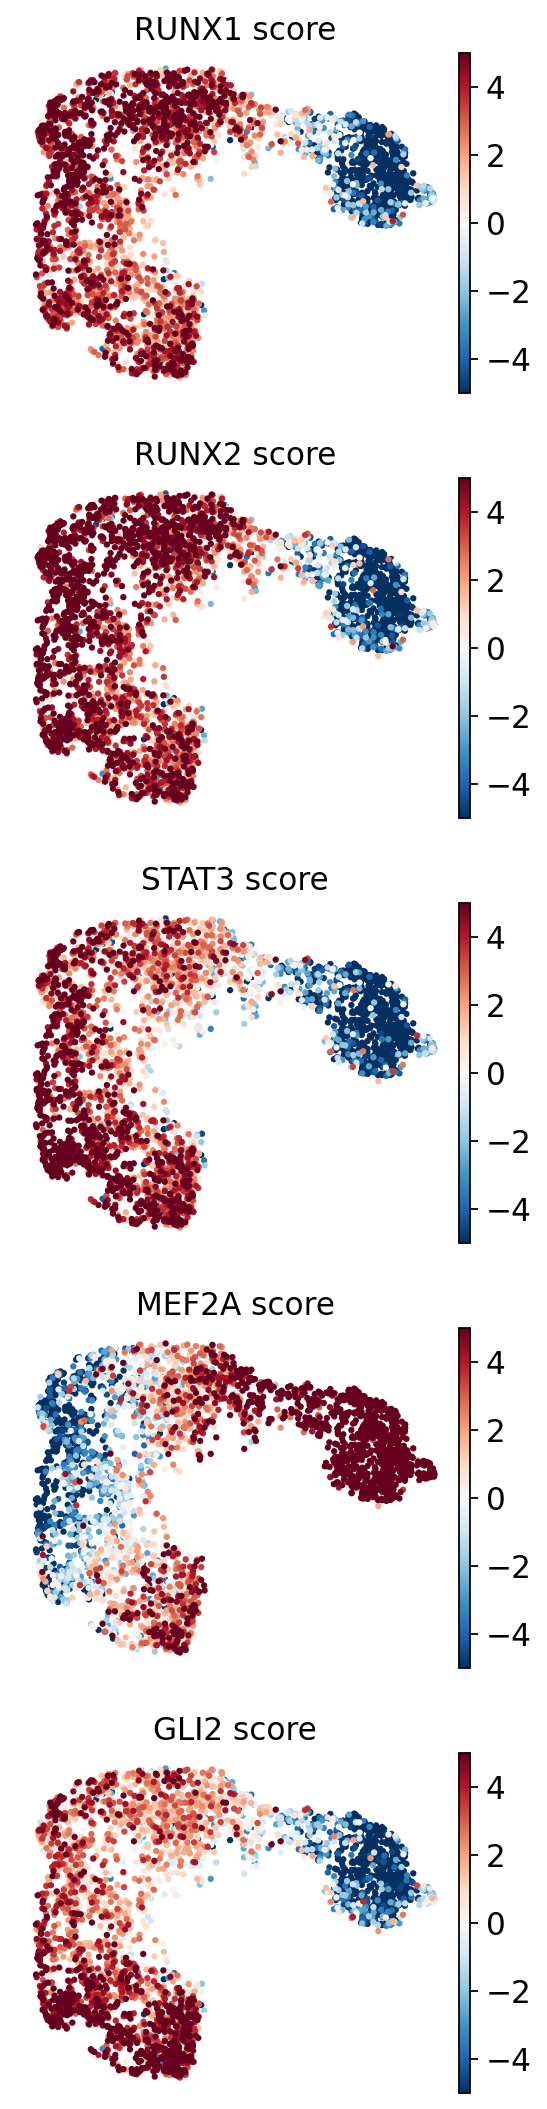

In [14]:
sc.pl.umap(score, color=top_tfs, cmap="RdBu_r", vmin=-5, vmax=5, ncols=1, title=[f"{t} score" for t in top_tfs],
save='PAGA_pvFIB_dpt_umap_top_tfs.png')

In [15]:
bin_tfs = dc.pp.bin_order(
    adata=score,
    order="dpt_pseudotime",
    names=top_tfs,
    label="v2.subclass.l3",
)
bin_tfs

,name,order,value,label,color
0,RUNX1,0.005,2.098577,pvFIB-PI16+,#ff7f0e
1,RUNX1,0.035,1.925533,pvFIB-PI16+,#ff7f0e
2,RUNX1,0.035,0.990244,pvFIB,#1f77b4
3,RUNX1,0.045,0.579933,pvFIB-RSPO3+,#279e68
4,RUNX1,0.045,2.415067,pvFIB-PI16+,#ff7f0e
...,...,...,...,...,...
18390,GLI2,0.905,1.753432,pvFIB-PI16+,#ff7f0e
18391,GLI2,0.915,0.816910,pvFIB-PI16+,#ff7f0e
18392,GLI2,0.925,0.157618,pvFIB-PI16+,#ff7f0e
18393,GLI2,0.965,1.929682,pvFIB-PI16+,#ff7f0e
